In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

In [2]:
FILE_PATH = Path.cwd().parent / "datasets" / "data.csv"

In [3]:
data = pd.read_csv(FILE_PATH)

In [4]:
# Mysterious empty column which cost me too much time and errors.
data.drop(columns=['Unnamed: 32','id'],inplace=True)

In [ ]:
data.shape # High Cardinallity 

(569, 31)

In [6]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
X = data.drop(columns= ['diagnosis']).values
y = data['diagnosis'].values

In [9]:
# We do this for splitting this into ratio so we can determine whether our prediction is correct or not
X_train , X_test  , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=2)

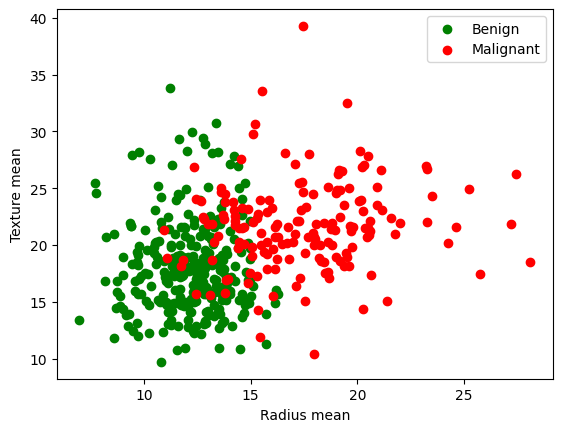

In [11]:
# Plotting this for two features
plt.scatter(X_train[y_train == 'B',0],X_train[y_train == 'B',1],color='green',label='Benign')
plt.scatter(X_train[y_train == 'M',0],X_train[y_train == 'M',1],color='red',label='Malignant')
plt.xlabel('Radius mean')
plt.ylabel('Texture mean')
plt.legend()
plt.show()

In [12]:
def euclidean_distance(a,b):
    return np.sqrt(np.sum((b-a)**2))

In [13]:
# Custom KNN Model from scratch which simply uses euclidean distance to calculate the distances to nearest point and based on their labels
# assign the majority class value to the random points
class KNN:
    def __init__(self,k):
        self.k = k
    
    def fit(self,X,y):
        self.X_train = X
        self.y_train = y

    def predict(self,new_points):
        predictions = [self.predict_class(new_point) for new_point in new_points]
        return np.array(predictions)
    
    def predict_class(self,new_point):
        distances = [euclidean_distance(point,new_point) for point in self.X_train]

        k_nearest_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_nearest_indices]

        most_common = Counter(k_nearest_labels).most_common(1)[0][0]

        return most_common

In [14]:
# For Testing the best K value
# for i in range(1,10):
#     knn = KNN(i)
#     knn.fit(X_train,y_train)
#     predictions = knn.predict(X_test)
#     accuracy = np.mean(predictions == y_test )*100
#     print(f" Accuracy : {accuracy :.2f} %")

In [15]:
knn = KNN(7)
knn.fit(X_train,y_train)
predictions = knn.predict(X_test)
accuracy = np.mean(predictions == y_test )*100
print(f" Accuracy : {accuracy :.2f} %")

 Accuracy : 92.98 %


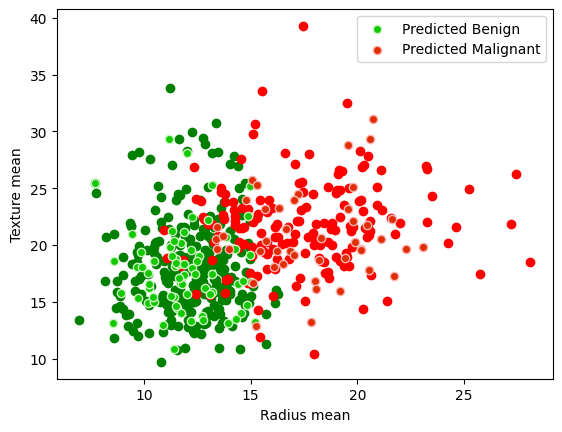

In [30]:
plt.scatter(X_train[y_train == 'B',0],X_train[y_train == 'B',1],color='green')
plt.scatter(X_train[y_train == 'M',0],X_train[y_train == 'M',1],color='red')
plt.scatter(X_test[predictions == 'B',0],X_test[predictions == 'B',1],color="#14C800",label='Predicted Benign',edgecolors="#C9F6C2")
plt.scatter(X_test[predictions == 'M',0],X_test[predictions == 'M',1],color="#E02E02",label='Predicted Malignant',edgecolors="#FFB4B4")
plt.legend()
plt.xlabel('Radius mean')
plt.ylabel('Texture mean')
plt.show()